In [25]:
import numpy as np
import pandas as pd
import librosa
import webrtcvad

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Reading a speech file

There are several Python libraries to work with audio files, but we used `librosa` since it provides a lot of functionality for looking at speech data. For processing purposes, we resample the audio file to 16 kHz.

In [46]:
# Load audio
y,sr = librosa.load(f"test_data/speech.wav", sr=16000, mono=True)
x = np.arange(0, len(y)/sr, 1/sr)
y = np.clip(y, -1, 1)
pcm16 = (y * 32767).astype(np.int16)

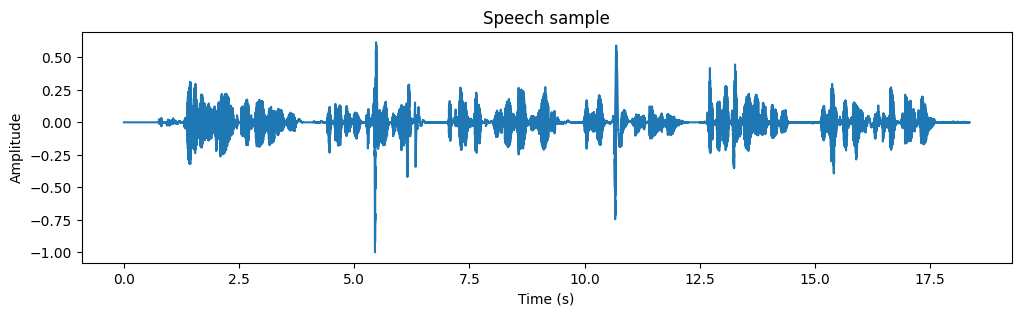

In [47]:
fig,ax = plt.subplots()
ax.plot(x,y)
ax.set_title("Speech sample")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
fig.set_size_inches(12,3)
plt.show()

# Voice activity detection

To analyze psychomotor rhythm in speech, we were interested in just capturing the production of any speech sound as a binary "ON" or "OFF" sequence. From there, we would be able to derive variables describing the durations of sounds and silences. To do this, we used the Python library `webrtcvad`, which is an interface to Google's WebRTC project. This projects implements an efficient method for Voice Activity Detection (VAD) which is commonly used in real-time applications; for example, digital calls via Zoom or Microsoft Teams can use this to only send audio when actual speech is detected.

In [ ]:
def frame_generator(frame_ms, pcm, sample_rate):
    """
    Generator that yields consecutive frames of a 16-bit PCM signal for a given frame length and sample rate.

    Parameters
    ----------
    frame_ms : int
        Length of the frame in ms. Expected to be either 10, 20, or 30 ms for webrtcvad.
    pcm : ndarray
        The PCM16 input array.
    sample_rate : int
        The sample rate of the audio signal. Expected to be either 8, 16, 32, or 48 kHz.

    Yields
    ------
    ndarray
        A single frame of the PCM16 data as raw bytes.
    """
    frame_len = int(sample_rate * frame_ms / 1000.0)
    timestamp = 0.0
    duration = frame_len / float(sample_rate)
    for start in range(0, len(pcm) - frame_len + 1, frame_len):
        yield pcm[start:start+frame_len].tobytes()
        timestamp += duration


def plot_result(mask, ax, label=None, color=None):
    """
    Helper function to plot the results of the voice activity detection.

    Parameters
    ----------
    mask : ndarray
        Boolean array of voice activity for each frame.
    ax : matplotlib.axes.Axes object
        Matplotlib axis to use for plotting.
    label : str
        Legend label for this VAD.
    color : str
        Matplotlib color for shading the voice activity.
    
    Returns
    -------
    NoneType
    """
    runs = []
    start = None
    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, len(mask) - 1))

    ax.plot(np.arange(0, len(y)/sr, 1/sr), y)
    for i, (s, e) in enumerate(runs):
        s *= 0.01
        e *= 0.01
        rect = patches.Rectangle((s, -0.25), e - s, 0.5, color=color, alpha=0.3, label=label if i==0 else None)
        ax.add_patch(rect)
    ax.set_title("Speech sample")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

`webrtcvad` also provides an option to modify the voice activity detection sensitivity with the `mode` parameter. Our recommendation is to consider trying different settings as part of model design, or include it as a hyperparameter if your sample size permits cross-validation.

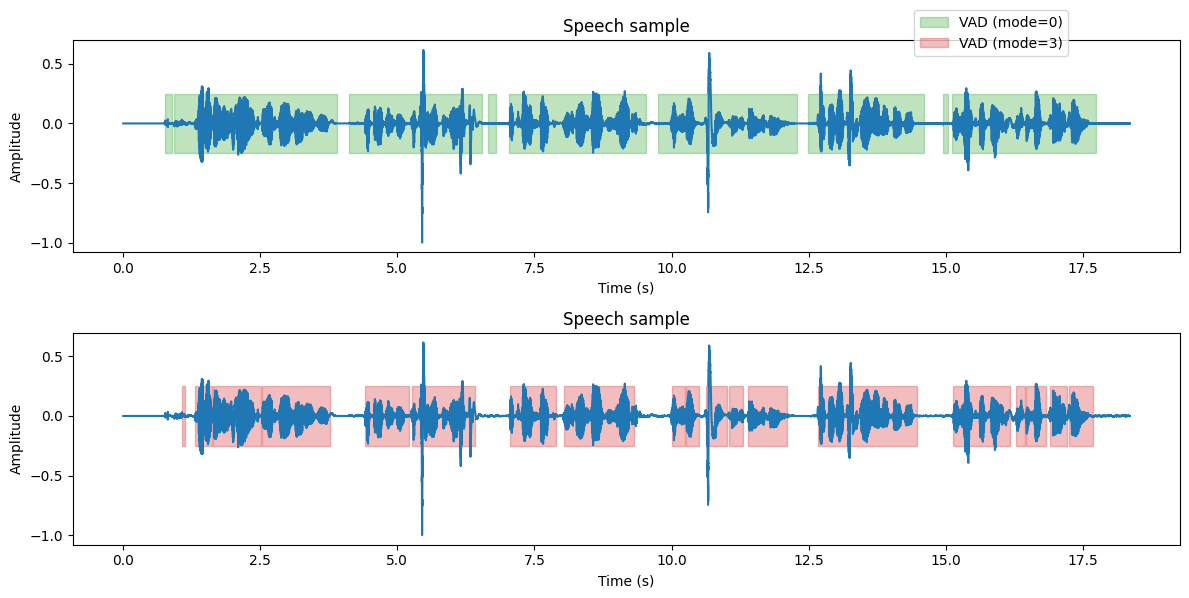

In [ ]:
fig,ax = plt.subplots(2,1)

# VAD mode can either be 0 (least agressive filter), 1, 2 or 3 (most agressive filter)
# Frame length can either be 10, 20, or 30 ms
MODE = 0
FRAME_LENGTH = 0.010
vad = webrtcvad.Vad(mode=MODE)
mask = np.array([vad.is_speech(b,sr) for b in frame_generator(FRAME_LENGTH*1000, pcm16, sr)])
plot_result(mask, ax[0], label="VAD (mode=0)", color="tab:green")

# Another configuration example
MODE = 3
FRAME_LENGTH = 0.010
vad = webrtcvad.Vad(mode=MODE)
mask = np.array([vad.is_speech(b,sr) for b in frame_generator(FRAME_LENGTH*1000, pcm16, sr)])
plot_result(mask, ax[1], label="VAD (mode=3)", color="tab:red")

# Display plot
fig.set_size_inches(12,6)
fig.legend(bbox_to_anchor=(0.9,1))
fig.tight_layout()
plt.show()

For downstream predictions, we can compute summary statistics of the speech activity to use as potential predictors. Here are some examples:

`speech_fraction`: proportion of time spent talking

`num_segments`: total number of speech segments

`speech_median`: median length (s) of a speech segment

`speech_logstd`: standard deviation of the log(length) of the speech segments -- may require several segments to be robustly estimated

`silence_median`: median length (s) of a non-speech segment

`silence_logstd`: standard deviation of the log(length) of the non-speech segments -- may require several segments to be robustly estimated

In [61]:
def run_lengths(mask, state=1):
    x = mask.astype(np.uint8)
    runs = []
    cnt = 0
    for z in x:
        if z == state:
            cnt += 1
        elif cnt:
            runs.append(cnt)
            cnt = 0
    if cnt: runs.append(cnt)
    return np.array(runs, int)

r1 = run_lengths(mask, state=1) * FRAME_LENGTH
r0 = run_lengths(mask, state=0) * FRAME_LENGTH
predictors = {
    "speech_fraction": mask.mean(),
    "num_segments": len(r1),
    "speech_median": np.median(r1) if r1.size > 0 else 0.0,
    "speech_logstd": np.std(np.log(r1), ddof=1),
    "silence_median": np.median(r0) if r0.size > 0 else 0.0,
    "silence_logstd": np.std(np.log(r0), ddof=1),
    "vad_mode": MODE
}

Here is an example dataframe entry for this speech sample.

In [62]:
final_df = pd.DataFrame.from_records([predictors])
final_df

,speech_fraction,num_segments,speech_median,speech_logstd,silence_median,silence_logstd,vad_mode
0,0.692643,19,0.44,0.841211,0.105,1.589018,3
